In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rxn_data = {
    "rxn_01": {"charge": 0, "spin": 3},  # 3
    "rxn_02": {"charge": 0, "spin": 2},  # 2
    "rxn_03": {"charge": 0, "spin": 1},  # 1
    "rxn_04": {"charge": 0, "spin": 2},  # 2
    "rxn_05": {"charge": 0, "spin": 0},  # 0 -> 2
    "rxn_06": {"charge": 0, "spin": 2},  # 2 -> 4
    "rxn_07": {"charge": 0, "spin": 1},  # 2 -> 4
    "rxn_08": {"charge": 0, "spin": 0},  # 2 -> 0
    "rxn_09": {"charge": 0, "spin": 1},  # 1 -> 3
    "rxn_10": {"charge": 0, "spin": 2},  # 2
    "rxn_11": {"charge": 0, "spin": 2},  # 2
    "rxn_12": {"charge": 0, "spin": 3},  # 3
    "rxn_13": {"charge": 0, "spin": 2},  # 2
    "rxn_14": {"charge": 0, "spin": 2},  # 2
    "rxn_15": {"charge": 0, "spin": 0},  # 0 -> 2
    "rxn_16": {"charge": 0, "spin": 1},  # 1
    "rxn_17": {"charge": 0, "spin": 1},  # 1
    "rxn_18": {"charge": 0, "spin": 2},  # 2
    "rxn_19": {"charge": 0, "spin": 1},  # 1
}

In [4]:
from pathlib import Path
from ase import Atoms, io
from typing import cast

reference: dict[str, list[Atoms]] = {
    file.stem: cast(list[Atoms], io.read(file, slice(None)))
    for file in sorted(Path("HCombustion-bso").glob("*.xyz"))
}

reactions: dict[str, list[Atoms]] = {
    file.stem: cast(list[Atoms], io.read(file, slice(None)))
    for file in sorted(Path("HCombustion-irc").glob("*.xyz"))
}

01_irc


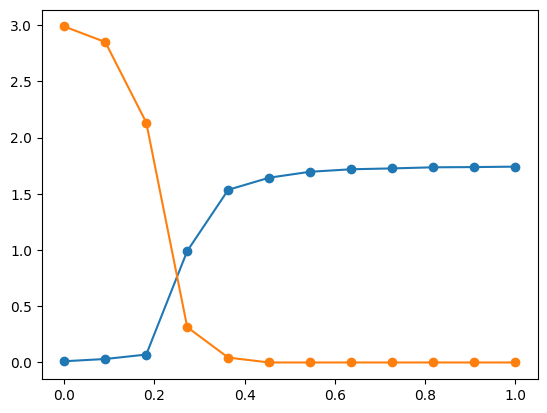

02_irc


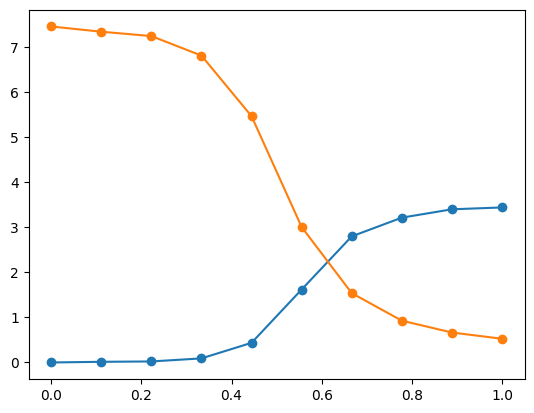

03_irc


KeyboardInterrupt: 

In [8]:
from bondspace.ase import PySCFCalculator, BondFluxCalculator

for rxn in reactions.keys():
    print(rxn)
    rxnname = "rxn_" + rxn.split("_")[0]
    irc = reactions[rxn]
    RS, TS, PS = reference[rxnname]

    rs_conn = [
        (int(row[0]), int(row[1]), float(np.round(row[2], 0)))
        for row in RS.info["connectivity"]
    ]
    ps_conn = [
        (int(row[0]), int(row[1]), float(np.round(row[2], 0)))
        for row in PS.info["connectivity"]
    ]

    idx = slice(0, len(irc), (len(irc) + 1) // 10)
    path = irc[idx]

    rs_energy = []
    ps_energy = []
    for at in path:
        at.calc = BondFluxCalculator(
            bonds=rs_conn, **rxn_data[rxnname], basis="cc-pvdz"
        )
        rs_energy.append(at.get_potential_energy())

        at.calc = BondFluxCalculator(
            bonds=ps_conn, **rxn_data[rxnname], basis="cc-pvdz"
        )
        ps_energy.append(at.get_potential_energy())

    plt.figure()
    xaxis = np.linspace(0, 1, len(path))
    plt.scatter(xaxis, rs_energy)
    plt.plot(xaxis, rs_energy)
    plt.scatter(xaxis, ps_energy)
    plt.plot(xaxis, ps_energy)
    plt.show()